In [39]:
import torch
import numpy as np
from torchcodec.decoders import VideoDecoder
from transformers import AutoVideoProcessor, AutoModel
from huggingface_hub.utils import enable_progress_bars
import matplotlib.pyplot as plt

enable_progress_bars()

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)
print('PyTorch version:', torch.__version__)

Using device: cuda
PyTorch version: 2.9.1+cu130


## Load Model and Processor

## Load Model and Processor

In [40]:
hf_repo = "facebook/vjepa2-vitl-fpc64-256"

print("Loading model and processor...")
model = AutoModel.from_pretrained(hf_repo).to(DEVICE)
processor = AutoVideoProcessor.from_pretrained(hf_repo)
print("Model and processor loaded successfully!")

Loading model and processor...
Model and processor loaded successfully!


## Load Video and Extract Frames

In [41]:
video_url = "../room6fps.mp4"
vr = VideoDecoder(video_url)

# Extract 64 frames starting from frame 200
start_frame = 0
frame_idx = np.arange(start_frame, start_frame + 64)
video_64_frames = vr.get_frames_at(indices=frame_idx).data  # T x C x H x W

print(f"Video shape: {video_64_frames.shape}")
print(f"Frame range: {start_frame} to {start_frame + 63}")

# Select a specific frame to test (let's use frame 32 - middle of the sequence)
test_frame_idx = 32
single_frame = video_64_frames[test_frame_idx:test_frame_idx+1]  # Keep shape as (1, C, H, W)

print(f"\nSingle frame shape: {single_frame.shape}")
print(f"Actual frame index in video: {start_frame + test_frame_idx}")

Video shape: torch.Size([64, 3, 1920, 1080])
Frame range: 0 to 63

Single frame shape: torch.Size([1, 3, 1920, 1080])
Actual frame index in video: 32


## Visualize the Test Frame

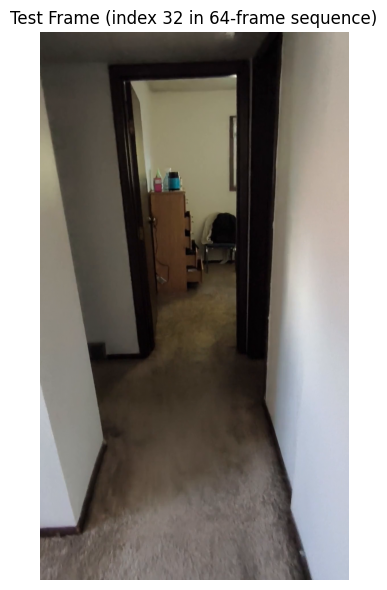

In [42]:
# Display the frame we're testing
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
frame_to_show = single_frame[0].permute(1, 2, 0).detach().cpu().numpy()
if frame_to_show.max() > 1.1:
    frame_to_show = frame_to_show / 255.0
ax.imshow(frame_to_show)
ax.axis('off')
ax.set_title(f"Test Frame (index {test_frame_idx} in 64-frame sequence)")
plt.tight_layout()
plt.show()

## Process and Extract Embeddings

### Scenario 1: Single Frame Alone

In [43]:
# Process single frame
# For a single image/frame, we need to create a video-like tensor by repeating it
print("Processing single frame...")
pixel_values_single = processor(single_frame, return_tensors="pt")["pixel_values_videos"].to(DEVICE)
print(f"Single frame pixel_values shape: {pixel_values_single.shape}")

# Extract embeddings
with torch.no_grad():
    embeddings_single = model.get_vision_features(pixel_values_single)


print(f"Single frame embeddings shape: {embeddings_single.shape}")# Expected: [1, num_patches_per_frame, 1024]

Processing single frame...
Single frame pixel_values shape: torch.Size([1, 1, 3, 256, 256])
Single frame embeddings shape: torch.Size([1, 256, 1024])


### Scenario 2: Same Frame as Part of 64-Frame Video

In [44]:
# Process entire 64-frame video
print("Processing 64-frame video...")
pixel_values_video = processor(video_64_frames, return_tensors="pt")["pixel_values_videos"].to(DEVICE)
print(f"Video pixel_values shape: {pixel_values_video.shape}")

# Extract embeddings
with torch.no_grad():
    embeddings_video = model.get_vision_features(pixel_values_video)

print(f"Video embeddings shape: {embeddings_video.shape}")
# Expected: [1, 8192, 1024] where 8192 = 64 frames * 128 patches/frame

Processing 64-frame video...
Video pixel_values shape: torch.Size([1, 64, 3, 256, 256])
Video embeddings shape: torch.Size([1, 8192, 1024])


## Extract the Corresponding Frame from Video Embeddings

In [45]:
# Calculate which tokens correspond to our test frame
# Note: The processor may structure tokens differently for single frames vs videos

print("Analyzing embedding structures...")
print(f"Single frame embeddings: {embeddings_single.shape}")
print(f"Video embeddings: {embeddings_video.shape}")

# Extract frame from video first to understand the structure
total_tokens_video = embeddings_video.shape[1]
num_frames_video = 64
patches_per_frame_video = total_tokens_video // num_frames_video

print(f"\nVideo structure:")
print(f"  Total tokens: {total_tokens_video}")
print(f"  Number of frames: {num_frames_video}")
print(f"  Patches per frame: {patches_per_frame_video}")

# Extract corresponding frame from video
print(f"\nExtracting frame {test_frame_idx} from video embeddings...")
start_token = test_frame_idx * patches_per_frame_video
end_token = (test_frame_idx + 1) * patches_per_frame_video

embeddings_from_video = embeddings_video[:, start_token:end_token, :]
print(f"  Token range: {start_token} to {end_token-1}")
print(f"  Extracted shape: {embeddings_from_video.shape}")

# Analyze single frame structure
total_tokens_single = embeddings_single.shape[1]
print(f"\nSingle frame structure:")
print(f"  Total tokens: {total_tokens_single}")

# Determine how many frames the single frame was repeated to
if total_tokens_single % patches_per_frame_video == 0:
    num_frames_in_single = total_tokens_single // patches_per_frame_video
    print(f"  Appears to be repeated to {num_frames_in_single} frames")
    print(f"  Patches per frame: {patches_per_frame_video}")
    
    # Extract first frame's patches from the repeated single frame
    embeddings_single_frame = embeddings_single[:, :patches_per_frame_video, :]
    print(f"  Extracting first frame: {embeddings_single_frame.shape}")
else:
    print(f"  Token count doesn't match expected frame structure")
    print(f"  Using all tokens as a single frame")
    embeddings_single_frame = embeddings_single

# Use the properly extracted single frame for comparison
embeddings_single = embeddings_single_frame
print(f"\n{'='*60}")
print("FINAL SHAPES FOR COMPARISON:")
print(f"  Single frame: {embeddings_single.shape}")
print(f"  From video:   {embeddings_from_video.shape}")
print('='*60)

Analyzing embedding structures...
Single frame embeddings: torch.Size([1, 256, 1024])
Video embeddings: torch.Size([1, 8192, 1024])

Video structure:
  Total tokens: 8192
  Number of frames: 64
  Patches per frame: 128

Extracting frame 32 from video embeddings...
  Token range: 4096 to 4223
  Extracted shape: torch.Size([1, 128, 1024])

Single frame structure:
  Total tokens: 256
  Appears to be repeated to 2 frames
  Patches per frame: 128
  Extracting first frame: torch.Size([1, 128, 1024])

FINAL SHAPES FOR COMPARISON:
  Single frame: torch.Size([1, 128, 1024])
  From video:   torch.Size([1, 128, 1024])


## Compare Embeddings

In [46]:
# Check if shapes match
print("Shape comparison:")
print(f"  Single frame: {embeddings_single.shape}")
print(f"  From video:   {embeddings_from_video.shape}")

if embeddings_single.shape != embeddings_from_video.shape:
    print("\n⚠️  Shapes don't match! The representations may be structured differently.")
else:
    print("\n✓ Shapes match!")

Shape comparison:
  Single frame: torch.Size([1, 128, 1024])
  From video:   torch.Size([1, 128, 1024])

✓ Shapes match!


In [47]:
# Compute differences
print("\n" + "="*60)
print("COMPARISON RESULTS")
print("="*60)

# Absolute difference
abs_diff = torch.abs(embeddings_single - embeddings_from_video)
max_abs_diff = abs_diff.max().item()
mean_abs_diff = abs_diff.mean().item()

print(f"\nAbsolute Difference:")
print(f"  Max:  {max_abs_diff:.6e}")
print(f"  Mean: {mean_abs_diff:.6e}")

# Relative difference (for non-zero elements)
mask = torch.abs(embeddings_single) > 1e-10
if mask.any():
    rel_diff = abs_diff[mask] / torch.abs(embeddings_single[mask])
    max_rel_diff = rel_diff.max().item()
    mean_rel_diff = rel_diff.mean().item()
    print(f"\nRelative Difference (for non-zero elements):")
    print(f"  Max:  {max_rel_diff:.6e}")
    print(f"  Mean: {mean_rel_diff:.6e}")

# Cosine similarity (for each patch)
cos_sim_per_patch = torch.nn.functional.cosine_similarity(
    embeddings_single[0], 
    embeddings_from_video[0], 
    dim=1
)
mean_cos_sim = cos_sim_per_patch.mean().item()
min_cos_sim = cos_sim_per_patch.min().item()

print(f"\nCosine Similarity (per patch, -1 to 1):")
print(f"  Mean: {mean_cos_sim:.6f}")
print(f"  Min:  {min_cos_sim:.6f}")

# Check if embeddings are identical (within numerical precision)
are_identical = torch.allclose(embeddings_single, embeddings_from_video, rtol=1e-5, atol=1e-8)
are_very_close = torch.allclose(embeddings_single, embeddings_from_video, rtol=1e-3, atol=1e-6)

print(f"\n" + "="*60)
if are_identical:
    print("✓ RESULT: Embeddings are IDENTICAL (within numerical precision)")
elif are_very_close:
    print("≈ RESULT: Embeddings are VERY CLOSE but not identical")
else:
    print("✗ RESULT: Embeddings are DIFFERENT")
print("="*60)


COMPARISON RESULTS

Absolute Difference:
  Max:  4.118450e+01
  Mean: 2.559952e+00

Relative Difference (for non-zero elements):
  Max:  3.565652e+05
  Mean: 1.052998e+01

Cosine Similarity (per patch, -1 to 1):
  Mean: 0.303838
  Min:  0.009341

✗ RESULT: Embeddings are DIFFERENT


## Visualize Difference Heatmap

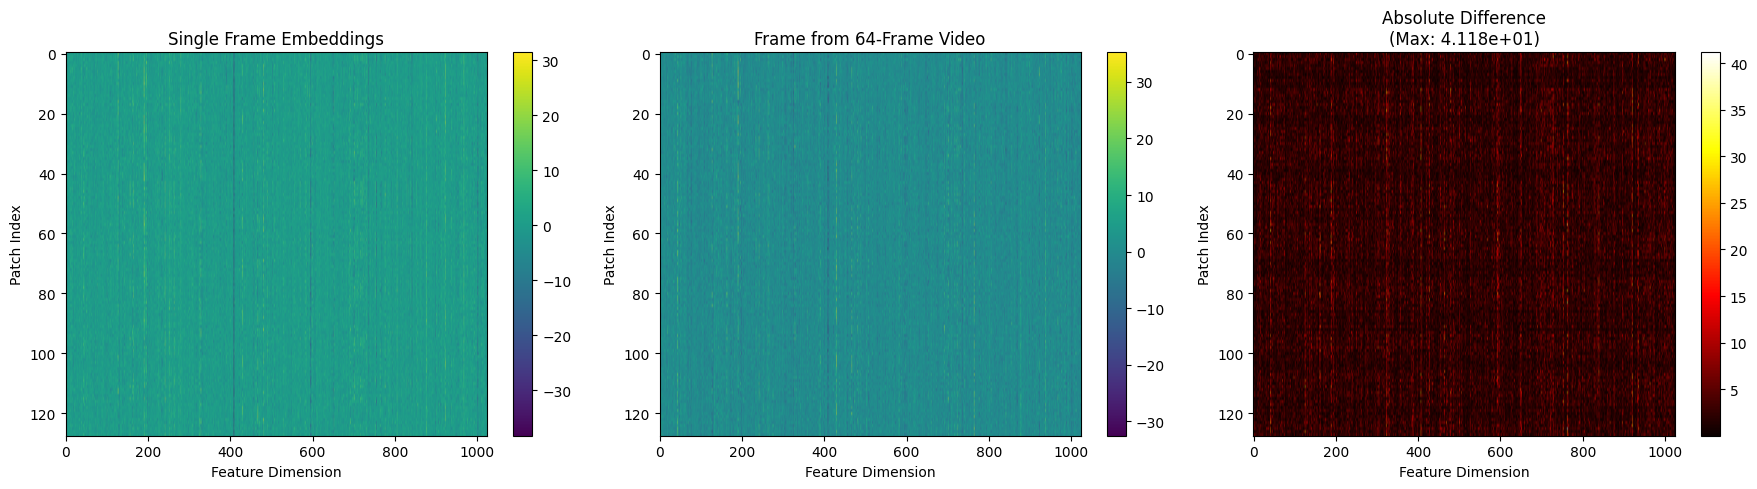

In [48]:
# Create heatmap of differences
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Heatmap 1: Single frame embeddings
im1 = axes[0].imshow(embeddings_single[0].cpu().numpy(), aspect='auto', cmap='viridis')
axes[0].set_title('Single Frame Embeddings')
axes[0].set_xlabel('Feature Dimension')
axes[0].set_ylabel('Patch Index')
plt.colorbar(im1, ax=axes[0])

# Heatmap 2: From video embeddings
im2 = axes[1].imshow(embeddings_from_video[0].cpu().numpy(), aspect='auto', cmap='viridis')
axes[1].set_title('Frame from 64-Frame Video')
axes[1].set_xlabel('Feature Dimension')
axes[1].set_ylabel('Patch Index')
plt.colorbar(im2, ax=axes[1])

# Heatmap 3: Absolute difference
im3 = axes[2].imshow(abs_diff[0].cpu().numpy(), aspect='auto', cmap='hot')
axes[2].set_title(f'Absolute Difference\n(Max: {max_abs_diff:.3e})')
axes[2].set_xlabel('Feature Dimension')
axes[2].set_ylabel('Patch Index')
plt.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()

## Summary Statistics Table

In [49]:
# Create a summary table
import pandas as pd

summary_data = {
    'Metric': [
        'Shape Match',
        'Max Absolute Difference',
        'Mean Absolute Difference',
        'Mean Cosine Similarity',
        'Min Cosine Similarity',
        'Identical (rtol=1e-5, atol=1e-8)',
        'Very Close (rtol=1e-3, atol=1e-6)'
    ],
    'Value': [
        '✓' if embeddings_single.shape == embeddings_from_video.shape else '✗',
        f'{max_abs_diff:.6e}',
        f'{mean_abs_diff:.6e}',
        f'{mean_cos_sim:.6f}',
        f'{min_cos_sim:.6f}',
        '✓' if are_identical else '✗',
        '✓' if are_very_close else '✗'
    ]
}

df_summary = pd.DataFrame(summary_data)
print("\n" + "="*60)
print("SUMMARY TABLE")
print("="*60)
print(df_summary.to_string(index=False))
print("="*60)


SUMMARY TABLE
                           Metric        Value
                      Shape Match            ✓
          Max Absolute Difference 4.118450e+01
         Mean Absolute Difference 2.559952e+00
           Mean Cosine Similarity     0.303838
            Min Cosine Similarity     0.009341
 Identical (rtol=1e-5, atol=1e-8)            ✗
Very Close (rtol=1e-3, atol=1e-6)            ✗


## Interpretation

### Expected Outcomes:

1. **If embeddings are IDENTICAL**: The model processes each frame independently, and temporal context from other frames doesn't affect individual frame representations.

2. **If embeddings are DIFFERENT**: The model uses temporal context from surrounding frames when processing the video, meaning each frame's representation is influenced by its position in the sequence.

### Implications:

- **Identical embeddings** suggest the model works like a per-frame encoder, making it suitable for tasks where frames can be processed independently.
- **Different embeddings** suggest the model incorporates temporal information, making it better for video understanding tasks but requiring full video context for consistent representations.